In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')



In [ ]:
df = pd.read_csv('/content/Advertising.csv')

# Drop index column if present
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print(" Dataset Shape:", df.shape)
print("\n First 5 rows:")
print(df.head())
print("\n Statistical Summary:")
print(df.describe())
print("\n Missing Values:")
print(df.isnull().sum())

 Dataset Shape: (200, 4)

 First 5 rows:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9

 Statistical Summary:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000

 Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


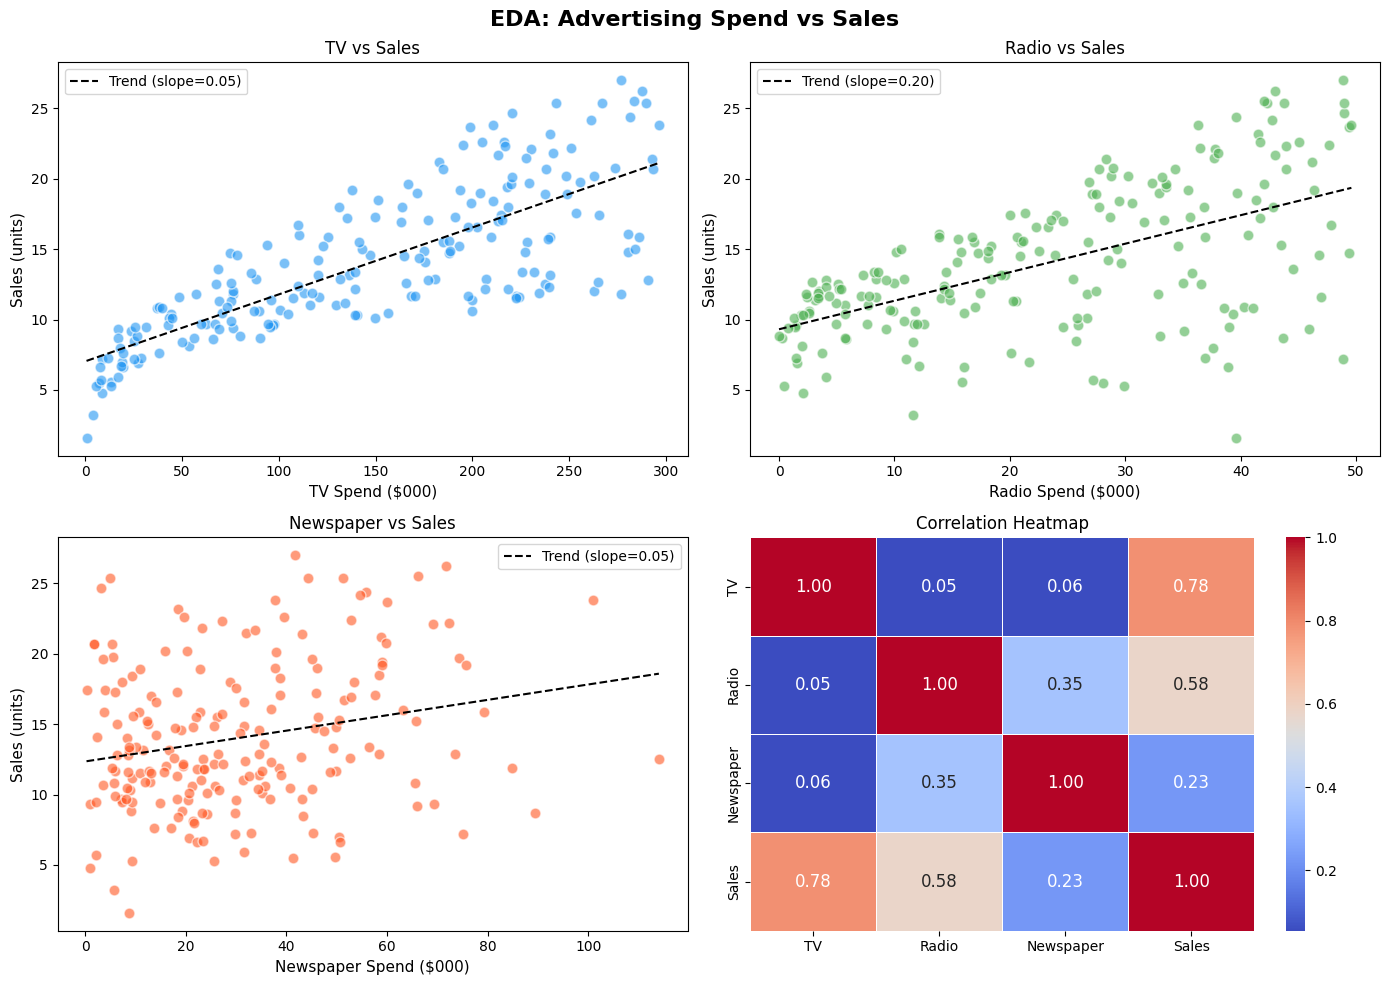

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA: Advertising Spend vs Sales', fontsize=16, fontweight='bold')

channels = ['TV', 'Radio', 'Newspaper']
colors   = ['#2196F3', '#4CAF50', '#FF5722']

for i, (ch, col) in enumerate(zip(channels, colors)):
    ax = axes[i // 2][i % 2]
    ax.scatter(df[ch], df['Sales'], alpha=0.6, color=col, edgecolors='white', s=60)
    m, b = np.polyfit(df[ch], df['Sales'], 1)
    x_line = np.linspace(df[ch].min(), df[ch].max(), 100)
    ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.5, label=f'Trend (slope={m:.2f})')
    ax.set_xlabel(f'{ch} Spend ($000)', fontsize=11)
    ax.set_ylabel('Sales (units)', fontsize=11)
    ax.set_title(f'{ch} vs Sales', fontsize=12)
    ax.legend()

# Correlation heatmap
ax4 = axes[1][1]
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax4,
            linewidths=0.5, annot_kws={'size': 12})
ax4.set_title('Correlation Heatmap', fontsize=12)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Interaction terms & log transforms
df['TV_Radio']        = df['TV'] * df['Radio']
df['TV_Newspaper']    = df['TV'] * df['Newspaper']
df['Radio_Newspaper'] = df['Radio'] * df['Newspaper']
df['TV_log']          = np.log1p(df['TV'])
df['Radio_log']       = np.log1p(df['Radio'])
df['Newspaper_log']   = np.log1p(df['Newspaper'])
df['Total_Spend']     = df['TV'] + df['Radio'] + df['Newspaper']
df['TV_share']        = df['TV'] / df['Total_Spend']

print(" Engineered features:", df.columns.tolist())

# Feature sets
X_basic    = df[['TV', 'Radio', 'Newspaper']]
X_extended = df[['TV', 'Radio', 'Newspaper',
                  'TV_Radio', 'TV_Newspaper', 'Radio_Newspaper',
                  'TV_log', 'Radio_log', 'Newspaper_log',
                  'Total_Spend', 'TV_share']]
y = df['Sales']

# Train-Test Split (80/20)
X_train_b, X_test_b, y_train, y_test = train_test_split(
    X_basic, y, test_size=0.2, random_state=42)
X_train_e, X_test_e, _, _ = train_test_split(
    X_extended, y, test_size=0.2, random_state=42)

# Scale basic features
scaler = StandardScaler()
X_train_b_sc = scaler.fit_transform(X_train_b)
X_test_b_sc  = scaler.transform(X_test_b)



 Engineered features: ['TV', 'Radio', 'Newspaper', 'Sales', 'TV_Radio', 'TV_Newspaper', 'Radio_Newspaper', 'TV_log', 'Radio_log', 'Newspaper_log', 'Total_Spend', 'TV_share']


In [ ]:
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    cv   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2, 'CV R²': cv,
            'y_pred': y_pred}

results = []
models  = {}

# Linear Regression
r = evaluate('Linear Regression', LinearRegression(),
             X_train_b_sc, X_test_b_sc, y_train, y_test)
results.append(r)

# Ridge Regression
r = evaluate('Ridge Regression', Ridge(alpha=1.0),
             X_train_b_sc, X_test_b_sc, y_train, y_test)
results.append(r)

# Lasso Regression
r = evaluate('Lasso Regression', Lasso(alpha=0.1),
             X_train_b_sc, X_test_b_sc, y_train, y_test)
results.append(r)

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
r  = evaluate('Random Forest', rf, X_train_e, X_test_e, y_train, y_test)
results.append(r)

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
r  = evaluate('Gradient Boosting', gb, X_train_e, X_test_e, y_train, y_test)
results.append(r)

metrics_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'y_pred'} for r in results])
metrics_df = metrics_df.sort_values('R²', ascending=False).reset_index(drop=True)

print("\n📊 MODEL COMPARISON:")
print(metrics_df.to_string(index=False))



📊 MODEL COMPARISON:
            Model     RMSE      MAE       R²    CV R²
Gradient Boosting 0.596958 0.461224 0.988710 0.986816
    Random Forest 0.607143 0.465187 0.988321 0.984333
Linear Regression 1.781600 1.460757 0.899438 0.859488
 Ridge Regression 1.787220 1.464301 0.898803 0.859662
 Lasso Regression 1.791334 1.461273 0.898336 0.861968


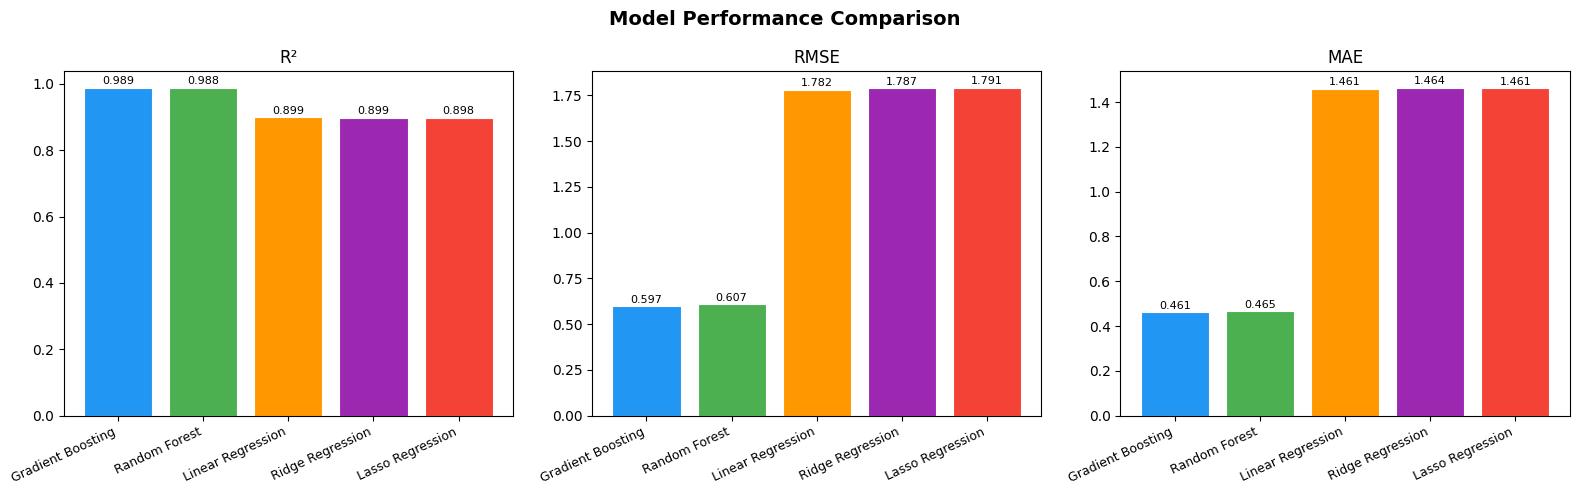

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

bar_kw = dict(color=['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336'],
              edgecolor='white', linewidth=0.8)

for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE']):
    vals = metrics_df[metric]
    bars = ax.bar(metrics_df['Model'], vals, **bar_kw)
    ax.set_title(metric, fontsize=12)
    ax.set_xticks(range(len(metrics_df)))
    ax.set_xticklabels(metrics_df['Model'], rotation=25, ha='right', fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005 * vals.max(),
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


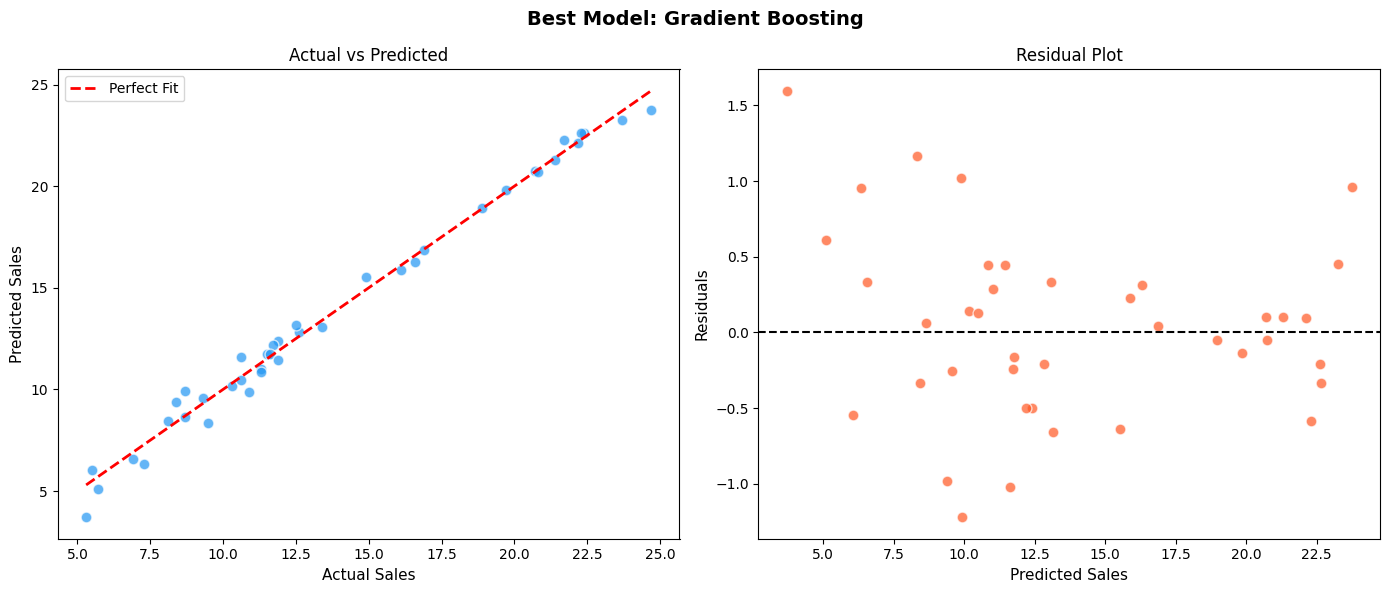

 Best model: Gradient Boosting
   R² = 0.9887  |  RMSE = 0.5970


In [ ]:
best_name   = metrics_df.iloc[0]['Model']
best_result = next(r for r in results if r['Model'] == best_name)
y_pred_best = best_result['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Best Model: {best_name}', fontsize=14, fontweight='bold')

# Actual vs Predicted
ax1 = axes[0]
ax1.scatter(y_test, y_pred_best, alpha=0.7, color='#2196F3', edgecolors='white', s=60)
mn, mx = y_test.min(), y_test.max()
ax1.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit')
ax1.set_xlabel('Actual Sales', fontsize=11)
ax1.set_ylabel('Predicted Sales', fontsize=11)
ax1.set_title('Actual vs Predicted', fontsize=12)
ax1.legend()

# Residuals
residuals = y_test.values - y_pred_best
ax2 = axes[1]
ax2.scatter(y_pred_best, residuals, alpha=0.7, color='#FF5722', edgecolors='white', s=60)
ax2.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Predicted Sales', fontsize=11)
ax2.set_ylabel('Residuals', fontsize=11)
ax2.set_title('Residual Plot', fontsize=12)

plt.tight_layout()
plt.savefig('best_model_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Best model: {best_name}")
print(f"   R² = {best_result['R²']:.4f}  |  RMSE = {best_result['RMSE']:.4f}")

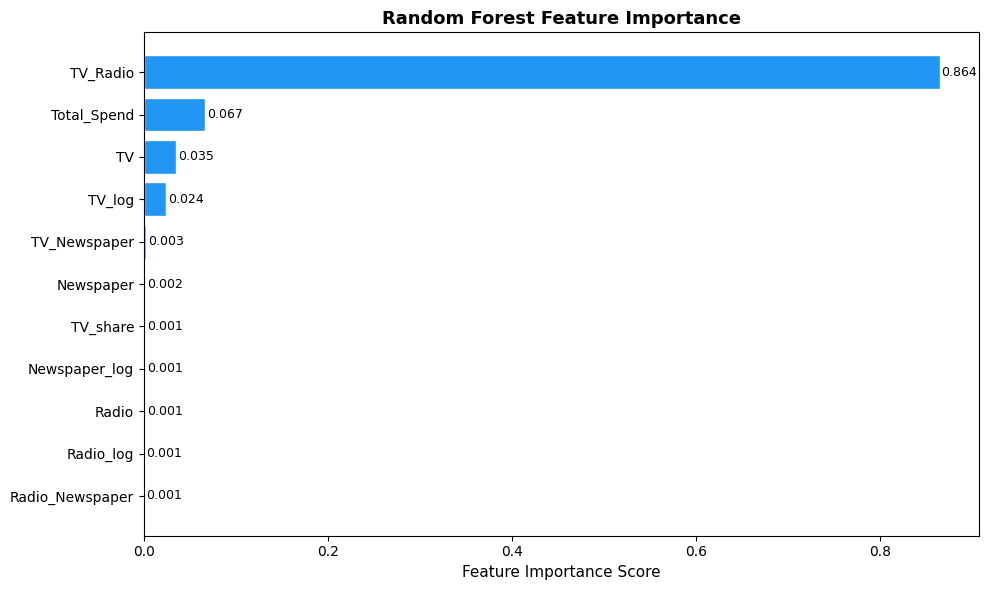


 Top Features:
        Feature  Importance
       TV_Radio    0.864263
    Total_Spend    0.066774
             TV    0.034932
         TV_log    0.024429
   TV_Newspaper    0.002735
      Newspaper    0.001652
       TV_share    0.001319
  Newspaper_log    0.001303
          Radio    0.001174
      Radio_log    0.000709
Radio_Newspaper    0.000708


In [ ]:
rf_final = RandomForestRegressor(n_estimators=200, random_state=42)
rf_final.fit(X_train_e, y_train)

importance_df = pd.DataFrame({
    'Feature':    X_extended.columns,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'],
                color='#2196F3', edgecolor='white')
plt.xlabel('Feature Importance Score', fontsize=11)
plt.title('Random Forest Feature Importance', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()

for bar, val in zip(bars, importance_df['Importance']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Top Features:")
print(importance_df.to_string(index=False))

In [ ]:
lr_raw = LinearRegression()
lr_raw.fit(X_train_b, y_train)

coeff_df = pd.DataFrame({
    'Channel':       ['TV', 'Radio', 'Newspaper'],
    'Coefficient':   lr_raw.coef_,
    'Impact per $1K': [f'+{c:.3f} units' for c in lr_raw.coef_]
})
print(" Linear Regression Coefficients (Sales units per $1K spend):")
print(coeff_df.to_string(index=False))
print(f"\n   Intercept: {lr_raw.intercept_:.3f}")

base_tv    = df['TV'].mean()
base_radio = df['Radio'].mean()
base_news  = df['Newspaper'].mean()
base_sales = lr_raw.predict([[base_tv, base_radio, base_news]])[0]

print(f"\n Scenario Analysis (base TV = ${base_tv:.1f}K):")
print(f"   Base predicted sales = {base_sales:.2f} units\n")

for pct in [10, 25, 50, 100]:
    new_tv    = base_tv * (1 + pct/100)
    new_sales = lr_raw.predict([[new_tv, base_radio, base_news]])[0]
    delta     = new_sales - base_sales
    print(f"   TV +{pct:3d}% → predicted sales = {new_sales:.2f} (Δ +{delta:.2f} units)")

 Linear Regression Coefficients (Sales units per $1K spend):
  Channel  Coefficient Impact per $1K
       TV     0.044730   +0.045 units
    Radio     0.189195   +0.189 units
Newspaper     0.002761   +0.003 units

   Intercept: 2.979

 Scenario Analysis (base TV = $147.0K):
   Base predicted sales = 14.04 units

   TV + 10% → predicted sales = 14.70 (Δ +0.66 units)
   TV + 25% → predicted sales = 15.69 (Δ +1.64 units)
   TV + 50% → predicted sales = 17.33 (Δ +3.29 units)
   TV +100% → predicted sales = 20.62 (Δ +6.58 units)



🔮 Predicting Sales for New Advertising Budgets...

 TV  Radio  Newspaper  Predicted_Sales
200     40         30            20.73
 50     10         20             9.37
150     25         15            15.32
100     35         50            14.14
280     45         10            26.15


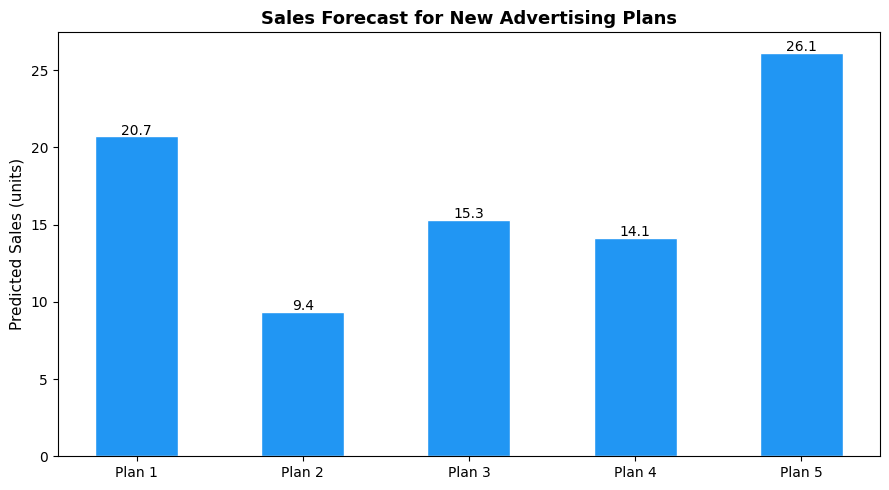

In [ ]:
print("\n🔮 Predicting Sales for New Advertising Budgets...\n")

new_data = pd.DataFrame({
    'TV':        [200, 50, 150, 100, 280],
    'Radio':     [40,  10,  25,  35,  45],
    'Newspaper': [30,  20,  15,  50,  10]
})

new_data['TV_Radio']        = new_data['TV'] * new_data['Radio']
new_data['TV_Newspaper']    = new_data['TV'] * new_data['Newspaper']
new_data['Radio_Newspaper'] = new_data['Radio'] * new_data['Newspaper']
new_data['TV_log']          = np.log1p(new_data['TV'])
new_data['Radio_log']       = np.log1p(new_data['Radio'])
new_data['Newspaper_log']   = np.log1p(new_data['Newspaper'])
new_data['Total_Spend']     = new_data['TV'] + new_data['Radio'] + new_data['Newspaper']
new_data['TV_share']        = new_data['TV'] / new_data['Total_Spend']

gb_final = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
gb_final.fit(X_train_e, y_train)

pred_sales = gb_final.predict(new_data[X_extended.columns])

result_df = new_data[['TV', 'Radio', 'Newspaper']].copy()
result_df['Predicted_Sales'] = pred_sales.round(2)
print(result_df.to_string(index=False))

plt.figure(figsize=(9, 5))
x = range(len(result_df))
plt.bar(x, result_df['Predicted_Sales'], color='#2196F3', edgecolor='white', width=0.5)
plt.xticks(x, [f"Plan {i+1}" for i in x])
plt.ylabel('Predicted Sales (units)', fontsize=11)
plt.title('Sales Forecast for New Advertising Plans', fontsize=13, fontweight='bold')
for i, val in enumerate(result_df['Predicted_Sales']):
    plt.text(i, val + 0.1, f'{val:.1f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('sales_forecast.png', dpi=150, bbox_inches='tight')
plt.show()